<a href="https://colab.research.google.com/github/GrCOTE7/deep_learning_course/blob/gc7/03-01_Compare_patience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import chrono
chrono.chrono()


In [2]:
import tensorflow as tf


In [3]:
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()


In [4]:
training_images.shape, test_images.shape


((60000, 28, 28), (10000, 28, 28))

In [5]:
labels = ["t-shirt/haut", "pantalon", "pull", "robe", "manteau", "sandales", "chemise",
"baskets", "sac", "bottines"]


In [6]:
labels[8]


'sac'

Images d'entrainement


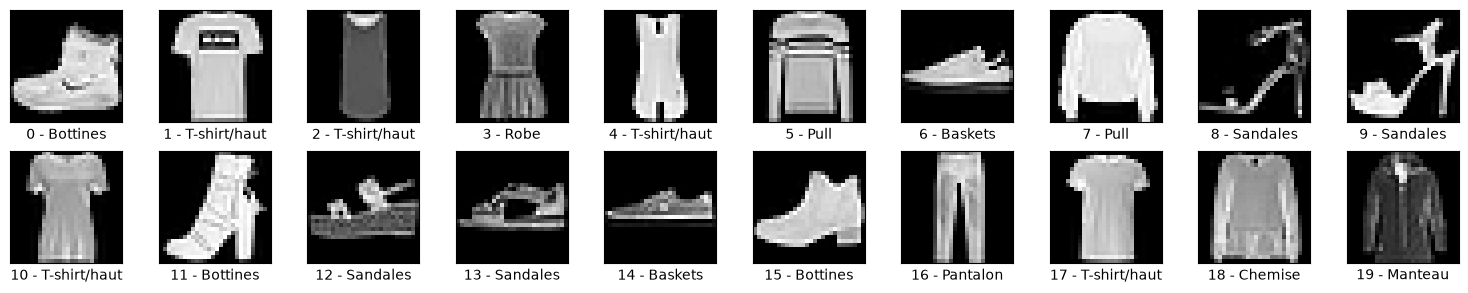

In [7]:
import matplotlib.pyplot as plt

# Choisir training ou test images en activant LA ligne ad'hoc
img_ids, img_labels = training_images, training_labels
# img_ids, img_labels = test_images, test_labels

# Calculate the number of rows and columns for the subplot grid
n_images = 20
n_cols = 10  # You can adjust the number of columns
n_rows = (n_images + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5)) # Adjust figure size as needed to accommodate xlabel

print("Images " +  ("d'entrainement" if img_labels.size== 60000 else 'de test'))

for i in range(n_images):
    plt.subplot(n_rows, n_cols, i + 1) # Create a subplot for each image
    plt.imshow(img_ids[i], cmap='gray')
    plt.xlabel(str(i) + ' - ' + labels[img_labels[i]].capitalize()) # Use xlabel for title below the image
    plt.xticks([]) # Remove x ticks
    plt.yticks([]) # Remove y ticks
    plt.axis('on') # Turn axis on to show xlabel

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()


In [8]:
# ==========================================================
# 1️⃣  Fixer la graine pour rendre les résultats reproductibles
# ==========================================================
import tensorflow as tf
import numpy as np
import random
import os

# Fixer la graine aléatoire (Pour avoir des résultats similaire avec un même param patience, appel& plusieurs fois)
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================================
# 2️⃣  Imports et préparation des données
# ==========================================================
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [9]:
ini_shape = training_images.shape
f_training_images = training_images.reshape((60000, 28*28)) # f_... comme flat_
f_test_images = test_images.reshape(-1, 28*28) # -1 = toutes les images du dataset

print('Applatissement des imges (Flatten): 28 x 28 = 784')
print('shape: ', ini_shape, ' → ', f_training_images.shape)

# Normalisation des données (moved from cell uf0-GJSPFcdl)
f_training_images = f_training_images / 255.0
f_test_images = f_test_images / 255.0


Applatissement des imges (Flatten): 28 x 28 = 784
shape:  (60000, 28, 28)  →  (60000, 784)


In [10]:
ini_shape = training_labels.shape
ini_label_img45 = training_labels[45]

training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

print('Classification (One Hot Encoding)')
print('shape: ', ini_shape, ' → ', training_labels.shape)
print('Classe img #45:', ini_label_img45, ' → ', training_labels[45])


Classification (One Hot Encoding)
shape:  (60000,)  →  (60000, 10)
Classe img #45: 2  →  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [11]:
import matplotlib.pyplot as plt

def graph4val(history, name='Early Stopping'):

    # Récupération des métriques
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Création de la figure
    plt.figure(figsize=(6, 4))

    # Accuracy
    plt.plot(epochs, acc, 'r-', label='Accuracy entraînement')
    plt.plot(epochs, val_acc, 'r--', label='Accuracy validation')

    # Loss
    plt.plot(epochs, loss, 'b-', label='Loss entraînement')
    plt.plot(epochs, val_loss, 'b--', label='Loss validation')

    # Mise en forme
    name = name.replace(" ", r"\ ")
    plt.title(rf"Evolution (accuracy & loss) $\mathbf{{{name}}}$")
    plt.xlabel("Epochs")
    plt.ylabel("Values")
    plt.legend(loc="center right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Test avec différentes valeursde la patience du Earliy Stopping

* patience in [3, 5, 7, 10, 12, 15, 21, 25]

In [12]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd # Ajout de l'import pour pandas

# Définir la liste des valeurs de patience
patience_values = [3, 5, 7, 10, 12, 15, 21, 25]
# patience_values = [1, 2, 3]
# Obtenir la valeur de patience maximale pour l'exécution d'entraînement unique
max_patience = max(patience_values)

# Normalisation des données (déplacé hors de la boucle)
# Vérifier si la normalisation a déjà été effectuée pour éviter de la répéter.
if np.max(f_training_images) > 1.0 or np.max(f_test_images) > 1.0:
    f_training_images = f_training_images / 255.0
    f_test_images = f_test_images / 255.0
    print("Données normalisées.")
else:
    print("Données déjà normalisées.")

# Dictionnaire pour stocker les résultats (sera rempli après l'entraînement)
results_summary = {}

print(f"\n--- Entraînement avec patience maximale = {max_patience} ---")
# Utiliser la patience maximale pour le nom de fichier de l'exécution d'entraînement unique
best_model_file = f"best_model_{max_patience}.h5"
history_file = f"training_history_{max_patience}.pkl"


# Construire et compiler le modèle (toujours repartir de zéro pour cette approche)
model = Sequential([
    Dense(units=784, activation="relu", input_shape=(784,)),
    tf.keras.layers.Dropout(0.5),
    Dense(units=128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    Dense(units=10, activation="softmax"),
])
model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=0.01),
    metrics=["accuracy"]
)

# Définir les callbacks en utilisant la patience maximale
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=max_patience, restore_best_weights=True)
model_ckp = ModelCheckpoint(
    filepath=best_model_file,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

# Entraîner le modèle une seule fois avec la patience maximale
h = model.fit(
    f_training_images, training_labels,
    epochs=1000, # Nombre élevé d'époques, EarlyStopping l'arrêtera
    validation_data=(f_test_images, test_labels),
    callbacks=[model_ckp, stop]
)

# Sauvegarder l'historique de l'entraînement
with open(history_file, 'wb') as f:
    pickle.dump(h, f)

print(f"\nEntraînement avec patience maximale ({max_patience}) terminé.")
print(f"Historique sauvegardé dans {history_file}")
print(f"Meilleur modèle sauvegardé dans {best_model_file}")

# Maintenant, traiter l'historique pour trouver les résultats pour toutes les valeurs de patience
print("\n--- Analyse de l'historique pour différentes valeurs de patience ---")

# Charger l'historique sauvegardé
with open(history_file, 'rb') as f:
    history = pickle.load(f)

# Extraire l'accuracy et la loss de validation
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']
epochs = range(1, len(val_accuracy) + 1)

# Trouver les meilleurs résultats pour chaque valeur de patience
for patience in patience_values:
    print(f"\nAnalyse pour patience = {patience}")
    best_val_acc_for_p = -1
    best_epoch_for_p = -1
    best_val_loss_for_p = -1
    last_best_epoch = 0 # Garder une trace de l'époque avec la meilleure val_accuracy rencontrée jusqu'à présent

    for i in range(len(val_accuracy)):
        current_val_acc = val_accuracy[i]

        # Mettre à jour la meilleure accuracy rencontrée jusqu'à présent et son époque
        if current_val_acc > val_accuracy[last_best_epoch]:
            last_best_epoch = i

        # Vérifier si l'arrêt anticipé se déclencherait à la fin de la fenêtre de patience
        # L'arrêt anticipé se déclenche si la val_accuracy à l'époque 'i' n'est pas meilleure que
        # le maximum de val_accuracy dans la fenêtre [i-patience, i-1].
        # Si l'époque actuelle est 'i', et que la meilleure accuracy était à 'last_best_epoch',
        # l'arrêt anticipé avec 'patience' se déclencherait à l'époque 'i' si
        # i - last_best_epoch >= patience.

        if (i - last_best_epoch) >= patience:
            # L'arrêt anticipé aurait eu lieu à l'époque 'i'.
            # La meilleure époque pour cette patience est celle avec la meilleure val_accuracy
            # dans l'historique *jusqu'à* l'époque précédant l'arrêt (époque i).
            # Cette meilleure époque est `last_best_epoch + 1`.
            best_epoch_idx_for_patience = last_best_epoch
            best_val_accuracy_for_patience = val_accuracy[best_epoch_idx_for_patience]
            best_val_loss_for_patience = val_loss[best_epoch_idx_for_patience]
            epochs_run_for_patience = i + 1 # L'époque à laquelle l'arrêt se produit

            results_summary[patience] = {
                'simulated_epochs_run': epochs_run_for_patience, # L'époque à laquelle l'arrêt s'est produit
                'best_epoch_in_simulated_run': best_epoch_idx_for_patience + 1, # L'époque avec la meilleure performance dans l'exécution simulée
                'best_val_accuracy_in_simulated_run': best_val_accuracy_for_patience,
                'best_val_loss_in_simulated_run': best_val_loss_for_patience
            }
            print(f"  Arrêt anticipé simulé à l'époque {epochs_run_for_patience}")
            print(f"  Meilleure époque pour patience {patience}: {best_epoch_idx_for_patience + 1}")
            print(f"  Meilleure val_accuracy: {best_val_accuracy_for_patience:.4f}")
            print(f"  Meilleure val_loss: {best_val_loss_for_patience:.4f}")

            # Passer à la prochaine valeur de patience car nous avons trouvé le résultat pour celle-ci
            break

        # Si la boucle se termine sans déclencher l'arrêt anticipé pour une valeur de patience,
        # cela signifie que l'entraînement a duré toute la durée de l'exécution avec la patience maximale.
        # Dans ce cas, le meilleur résultat pour cette patience est le meilleur résultat global
        # trouvé pendant toute l'exécution avec la patience maximale.
        if i == len(val_accuracy) - 1 and patience not in results_summary:
             best_val_accuracy_overall = max(val_accuracy)
             best_epoch_overall_idx = val_accuracy.index(best_val_accuracy_overall)
             best_epoch_overall = best_epoch_overall_idx + 1
             best_val_loss_overall = val_loss[best_epoch_overall_idx]

             results_summary[patience] = {
                'simulated_epochs_run': len(val_accuracy),
                'best_epoch_in_simulated_run': best_epoch_overall,
                'best_val_accuracy_in_simulated_run': best_val_accuracy_overall,
                'best_val_loss_in_simulated_run': best_val_loss_overall
            }
             print(f"  L'arrêt anticipé ne s'est pas déclenché pour patience {patience}.")
             print(f"  Meilleure époque (exécution globale): {best_epoch_overall}")
             print(f"  Meilleure val_accuracy (exécution globale): {best_val_accuracy_overall:.4f}")
             print(f"  Meilleure val_loss (exécution globale): {best_val_loss_overall:.4f}")


# Afficher le tableau récapitulatif
print("\n--- Tableau Récapitulatif des Résultats (Analyse de l'historique) ---")
# Convertir results_summary en DataFrame
results_df = pd.DataFrame.from_dict(results_summary, orient='index')
results_df.index.name = 'Patience'
# Renommer les colonnes pour plus de clarté
results_df = results_df.rename(columns={
    'simulated_epochs_run': 'Époques Exécutées (Simulé)',
    'best_epoch_in_simulated_run': 'Meilleure Époque (Simulé)',
    'best_val_accuracy_in_simulated_run': 'Meilleure Val Accuracy',
    'best_val_loss_in_simulated_run': 'Meilleure Val Loss'
})
display(results_df)


Données déjà normalisées.

--- Entraînement avec patience maximale = 25 ---


d:\Py\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5987 - loss: 1.1485

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6992 - loss: 0.8612 - val_accuracy: 0.8028 - val_loss: 0.5616
Epoch 2/1000
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7871 - loss: 0.6069

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7978 - loss: 0.5794 - val_accuracy: 0.8282 - val_loss: 0.4880
Epoch 3/1000
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8154 - loss: 0.5244

...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9267 - loss: 0.1987 - val_accuracy: 0.8980 - val_loss: 0.2980
Epoch 80/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9265 - loss: 0.1962 - val_accuracy: 0.8959 - val_loss: 0.3046
Epoch 81/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9278 - loss: 0.1960 - val_accuracy: 0.8942 - val_loss: 0.3082
Epoch 82/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9286 - loss: 0.1944 - val_accuracy: 0.8969 - val_loss: 0.3037
Epoch 83/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9278 - loss: 0.1933 - val_accuracy: 0.8971 - val_loss: 0.3077
Epoch 84/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9276 - loss: 0.1922 - val_accuracy: 0.8948 - val_loss: 0.3078
Epoch 85/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9284 - loss: 0.1911 - val_accuracy: 0.8955 - val_loss: 0.3048
Epoch 86/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9304

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9297 - loss: 0.1888 - val_accuracy: 0.8991 - val_loss: 0.3003
Epoch 88/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9308 - loss: 0.1864 - val_accuracy: 0.8963 - val_loss: 0.3065
Epoch 89/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9303 - loss: 0.1872 - val_accuracy: 0.8975 - val_loss: 0.3059
Epoch 90/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9305 - loss: 0.1852 - val_accuracy: 0.8951 - val_loss: 0.3074
Epoch 91/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9309 - loss: 0.1851 - val_accuracy: 0.8954 - val_loss: 0.3106
Epoch 92/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9327 - loss: 0.1831 - val_accuracy: 0.8977 - val_loss: 0.3012
Epoch 93/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9315 - loss: 0.1813 - val_accuracy: 0.8965 - val_loss: 0.3083
Epoch 94/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9320 -

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9338 - loss: 0.1760 - val_accuracy: 0.8997 - val_loss: 0.3010
Epoch 98/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9350 - loss: 0.1745 - val_accuracy: 0.8948 - val_loss: 0.3054
Epoch 99/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9344 - loss: 0.1762 - val_accuracy: 0.8973 - val_loss: 0.3050
Epoch 100/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9356 - loss: 0.1716 - val_accuracy: 0.8971 - val_loss: 0.3071
Epoch 101/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9367 - loss: 0.1708 - val_accuracy: 0.8986 - val_loss: 0.3037
Epoch 102/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9352 - loss: 0.1708 - val_accuracy: 0.8973 - val_loss: 0.3101
Epoch 103/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9363 - loss: 0.1702 - val_accuracy: 0.8972 - val_loss: 0.3051
Epoch 104/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9372 

d:\Py\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,Époques Exécutées (Simulé),Meilleure Époque (Simulé),Meilleure Val Accuracy,Meilleure Val Loss
Patience,,,,
3,30,27,0.8820,0.329886
5,45,40,0.8884,0.315901
7,47,40,0.8884,0.315901
10,107,97,0.8997,0.300989
12,109,97,0.8997,0.300989
15,112,97,0.8997,0.300989
21,118,97,0.8997,0.300989
25,122,97,0.8997,0.300989



--- Visualisation des Résultats ---


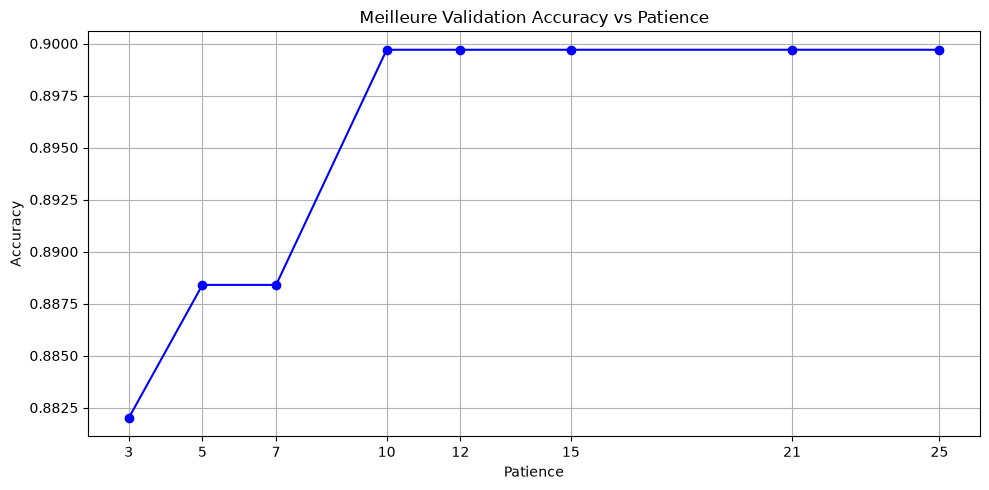

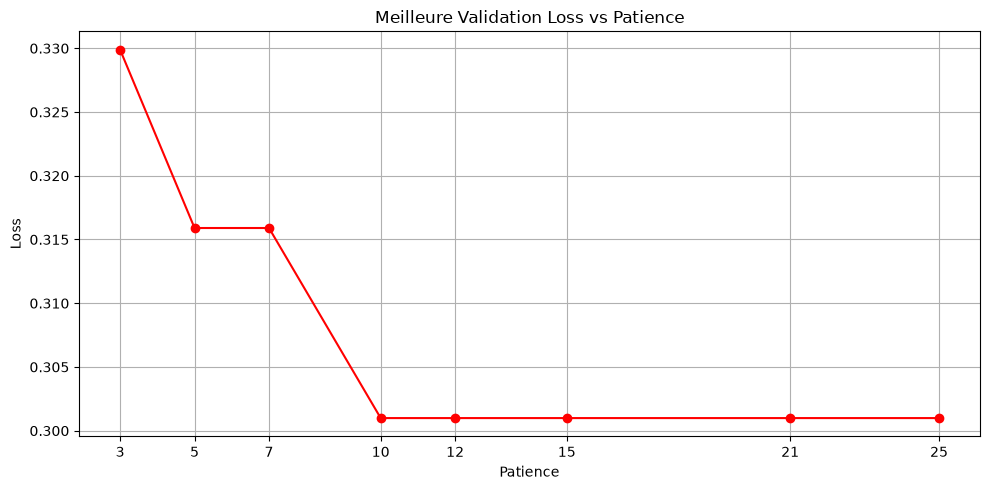

In [13]:
import matplotlib.pyplot as plt
import pandas as pd # Make sure pandas is imported

# Assuming results_df is already created and populated in a previous cell

if 'results_df' in locals() and not results_df.empty:
    print("\n--- Visualisation des Résultats ---")

    # Plotting Best Validation Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(results_df.index, results_df['Meilleure Val Accuracy'], marker='o', linestyle='-', color='b')
    plt.title('Meilleure Validation Accuracy vs Patience')
    plt.xlabel('Patience')
    plt.ylabel('Accuracy')
    plt.xticks(results_df.index) # Set x-ticks to patience values
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plotting Best Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(results_df.index, results_df['Meilleure Val Loss'], marker='o', linestyle='-', color='r')
    plt.title('Meilleure Validation Loss vs Patience')
    plt.xlabel('Patience')
    plt.ylabel('Loss')
    plt.xticks(results_df.index) # Set x-ticks to patience values
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Le DataFrame results_df n'existe pas ou est vide. Veuillez exécuter la cellule de calcul des résultats.")


In [14]:
import pandas as pd

print("\n--- Tableau Récapitulatif des Résultats ---")
results_df = pd.DataFrame.from_dict(results_summary, orient='index')
results_df.index.name = 'Patience'
display(results_df)



--- Tableau Récapitulatif des Résultats ---


,simulated_epochs_run,best_epoch_in_simulated_run,best_val_accuracy_in_simulated_run,best_val_loss_in_simulated_run
Patience,,,,
3,30,27,0.8820,0.329886
5,45,40,0.8884,0.315901
7,47,40,0.8884,0.315901
10,107,97,0.8997,0.300989
12,109,97,0.8997,0.300989
15,112,97,0.8997,0.300989
21,118,97,0.8997,0.300989
25,122,97,0.8997,0.300989


In [15]:
import os

for file in os.listdir('.'):
    if file.endswith('.h5'):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"{file:40s}  {size:8.2f} Mo")


aug_model.h5                                 19.89 Mo
best_model.h5                                 2.76 Mo
best_model_25.h5                              2.76 Mo


In [16]:
import os

# Répertoire où chercher les fichiers (. = répertoire courant)
folder = '.'

# Liste tous les fichiers .h5 du dossier (et sous-dossiers si tu veux)
h5_files = []
for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith('.h5'):
            filepath = os.path.join(root, file)
            size_mb = os.path.getsize(filepath) / (1024 * 1024)  # taille en Mo
            h5_files.append((filepath, size_mb))

# Affichage formaté
if h5_files:
    print(f"{'Fichier':60s} | Taille (Mo)")
    print("-" * 80)
    for name, size in h5_files:
        print(f"{name:60s} | {size:10.2f}")
else:
    print("Aucun fichier .h5 trouvé dans le dossier courant.")


Fichier                                                      | Taille (Mo)
--------------------------------------------------------------------------------
.\aug_model.h5                                               |      19.89
.\best_model.h5                                              |       2.76
.\best_model_25.h5                                           |       2.76
.\CNN_Streamlit_APP\best_model.h5                            |      19.88


In [17]:
chrono.chrono()


Temps écoulé : 00:20:26.40
